# Лабораторная работа 3 — Fine-tuning
**Смирнов Александр Сергеевич**

Классификация самостоятельно отобранных фотографий трёх видов насекомых из Wikimedia Commons.
Авторы и лицензии приведены в `experiments/data/sources.csv`. Фотографии не сделаны студентом.
Сравниваем ResNet18 и MobileNetV3 Small из timm на CPU. Все результаты ниже вычисляются кодом.
Ноутбук нужно запускать из клонированного репозитория; исходные изображения уже включены.


In [1]:
from pathlib import Path
import os, sys, json, csv, platform
from dataclasses import asdict, replace
import numpy as np
from IPython.display import display, Image as DisplayImage, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'experiments/train.py').exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from experiments.train import TrainConfig, prepare_split, train, test_checkpoint, export_checkpoint, set_seed
set_seed(42)
print('Python', platform.python_version(), 'CPU', platform.processor())
import torch, timm
print('PyTorch', torch.__version__, 'timm', timm.__version__, 'CUDA', torch.cuda.is_available())

D:\Univercity\Neuro\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python 3.12.14 CPU Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
PyTorch 2.14.0+cpu timm 1.0.29 CUDA False


## Данные и протокол
Три класса: butterfly — Danaus plexippus, dragonfly — Anax imperator, ladybird — Coccinella septempunctata.
Это классификация между тремя конкретными видами, а не универсальный определитель всех насекомых.
Из поиска исключены рисунки, личинки, коллекционные экземпляры и неоднозначные сцены; затем выполнен визуальный контроль.
Разделение около 60/20/20 группируется по автору: один автор не встречается в разных частях.
Метаданные и состав частей фиксируются до обучения. Тест не участвует в подборе.


butterfly {'train': 22, 'val': 7, 'test': 7}
dragonfly {'train': 23, 'val': 7, 'test': 9}
ladybird {'train': 24, 'val': 8, 'test': 9}


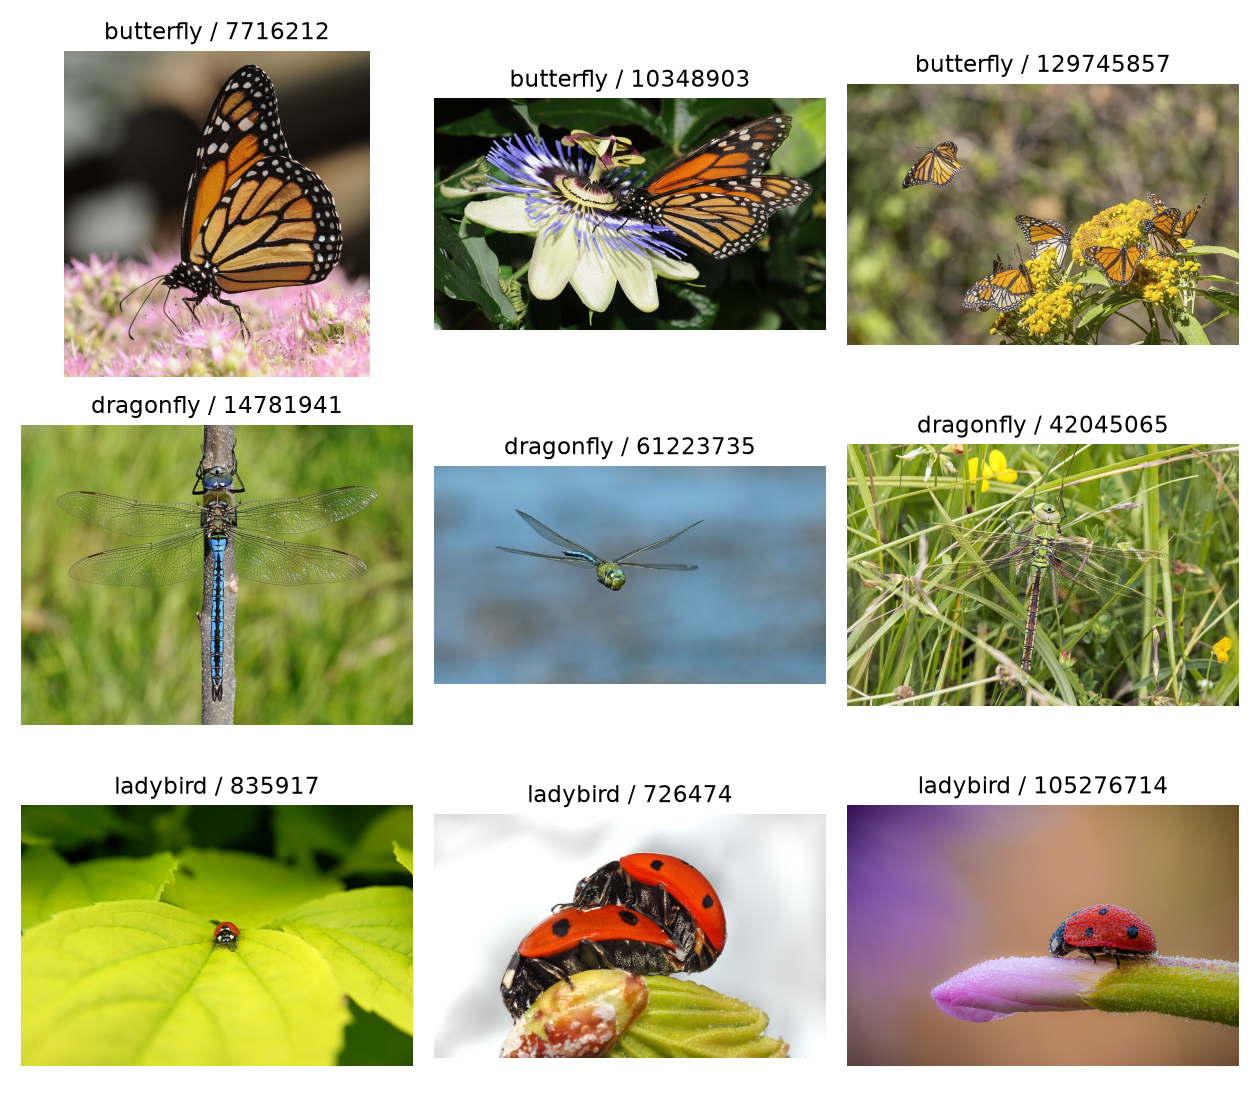

In [2]:
rows = list(csv.DictReader(open('experiments/data/processed/split.csv', encoding='utf-8')))
classes = sorted({r['label'] for r in rows})
for c in classes:
    print(c, {s: sum(r['label']==c and r['split']==s for r in rows) for s in ['train','val','test']})
groups = {s: {r['group'] for r in rows if r['split']==s} for s in ['train','val','test']}
assert not groups['train'] & groups['val'] and not groups['train'] & groups['test'] and not groups['val'] & groups['test']
assert len({r['sha256'] for r in rows}) == len(rows)
display(DisplayImage(filename='experiments/reports/figures/examples.png'))

## Архитектуры и стратегия
ResNet18 использует остаточные связи; MobileNetV3 Small — компактные блоки с depthwise-свёртками.
Обе сети загружаются с `pretrained=True`, классификатор заменяется на три выхода.
Первые две эпохи обучается голова, backbone и статистики BatchNorm заморожены. Затем размораживается вся сеть.
AdamW: шаг backbone в 10 раз меньше шага головы, weight decay 1e-4.
При переходе создаётся новый оптимизатор для нового этапа.
Аугментации только train: случайный crop 75–100% площади, горизонтальное отражение, умеренный ColorJitter.
Eval и приложение вызывают одну функцию: EXIF→RGB→центральный квадрат BICUBIC 160×160→ImageNet normalization→CHW float32.


## Подбор гиперпараметров
Фиксированная сетка: две архитектуры × два шага головы (0.001 и 0.0003), backbone=head/10.
Каждый запуск: 6 эпох, batch=8, seed=42, 2 CPU threads. Такая сетка ограничивает стоимость CPU-эксперимента.
Для каждого запуска выбирается эпоха с максимальной validation accuracy, при равенстве — минимальным validation loss.
Затем тем же критерием выбирается запуск в семействе и общая лучшая модель. Test открывается после выбора.


In [3]:
configs = []
for family, model in [('resnet18','resnet18.a1_in1k'), ('mobilenetv3','mobilenetv3_small_100.lamb_in1k')]:
    for lr, tag in [(1e-3,'001'), (3e-4,'0003')]:
        configs.append(TrainConfig(model=model, lr_head=lr, lr_backbone=lr/10, run_name=f'{family}_lr{tag}'))
Path('experiments/configs').mkdir(exist_ok=True)
runs = []
for config in configs:
    Path(f'experiments/configs/{config.run_name}.json').write_text(json.dumps(asdict(config), indent=2))
    runs.append(train(config))
Path('experiments/reports/search.json').write_text(json.dumps(runs, indent=2))

D:\Univercity\Neuro\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Alexandr\.cache\huggingface\hub\models--timm--resnet18.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


resnet18_lr001 {'epoch': 1, 'stage': 'head', 'train_loss': 1.0698624641998955, 'train_accuracy': 0.43478260869565216, 'val_loss': 0.8532678213986483, 'val_accuracy': 0.9090909090909091}


resnet18_lr001 {'epoch': 2, 'stage': 'head', 'train_loss': 0.7911216262458027, 'train_accuracy': 0.8840579710144928, 'val_loss': 0.6267333030700684, 'val_accuracy': 1.0}


resnet18_lr001 {'epoch': 3, 'stage': 'all', 'train_loss': 0.971261713815772, 'train_accuracy': 0.5652173913043478, 'val_loss': 0.6495292945341631, 'val_accuracy': 0.9545454545454546}


resnet18_lr001 {'epoch': 4, 'stage': 'all', 'train_loss': 0.7701970788015835, 'train_accuracy': 0.8695652173913043, 'val_loss': 0.6480328603224321, 'val_accuracy': 0.9545454545454546}


...

mobilenetv3_lr0003 {'epoch': 3, 'stage': 'all', 'train_loss': 4.700315807176673, 'train_accuracy': 0.37681159420289856, 'val_loss': 3.1191288341175425, 'val_accuracy': 0.36363636363636365}


mobilenetv3_lr0003 {'epoch': 4, 'stage': 'all', 'train_loss': 1.685433522514675, 'train_accuracy': 0.5797101449275363, 'val_loss': 1.9580900885842063, 'val_accuracy': 0.6363636363636364}


mobilenetv3_lr0003 {'epoch': 5, 'stage': 'all', 'train_loss': 0.8918037518211033, 'train_accuracy': 0.782608695652174, 'val_loss': 1.3806982907381924, 'val_accuracy': 0.7272727272727273}


mobilenetv3_lr0003 {'epoch': 6, 'stage': 'all', 'train_loss': 0.7960032968633417, 'train_accuracy': 0.8695652173913043, 'val_loss': 1.377146764235063, 'val_accuracy': 0.7272727272727273}


8658

resnet18_lr001 val accuracy 1.0 val loss 0.6267 seconds 22.3 parameters 11178051


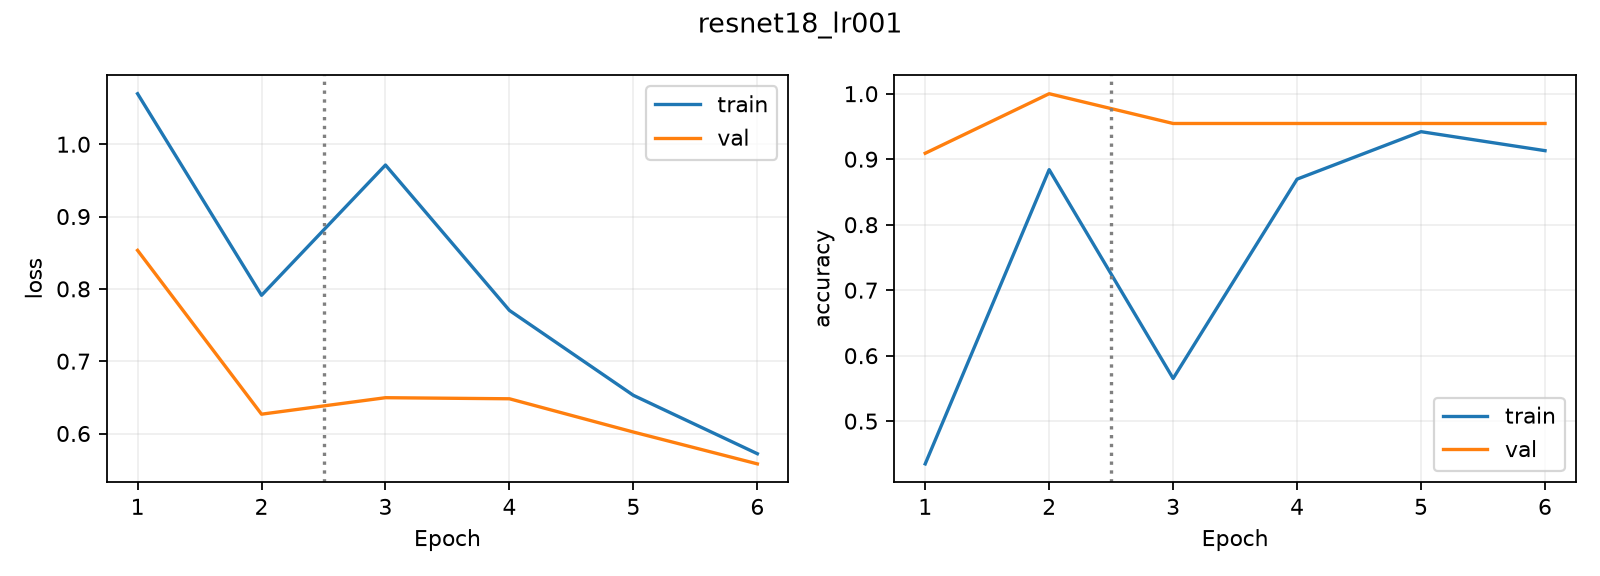

resnet18_lr0003 val accuracy 0.8182 val loss 0.9515 seconds 21.5 parameters 11178051


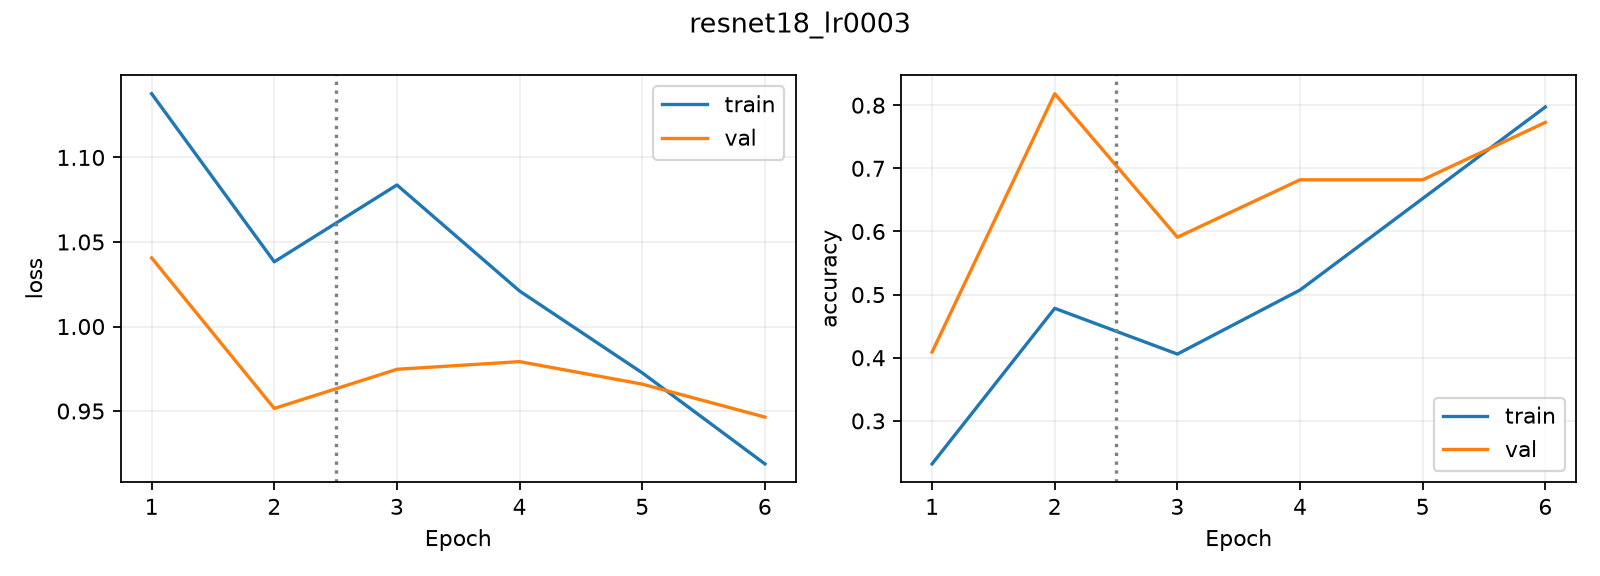

mobilenetv3_lr001 val accuracy 0.8636 val loss 0.4337 seconds 9.0 parameters 1520931


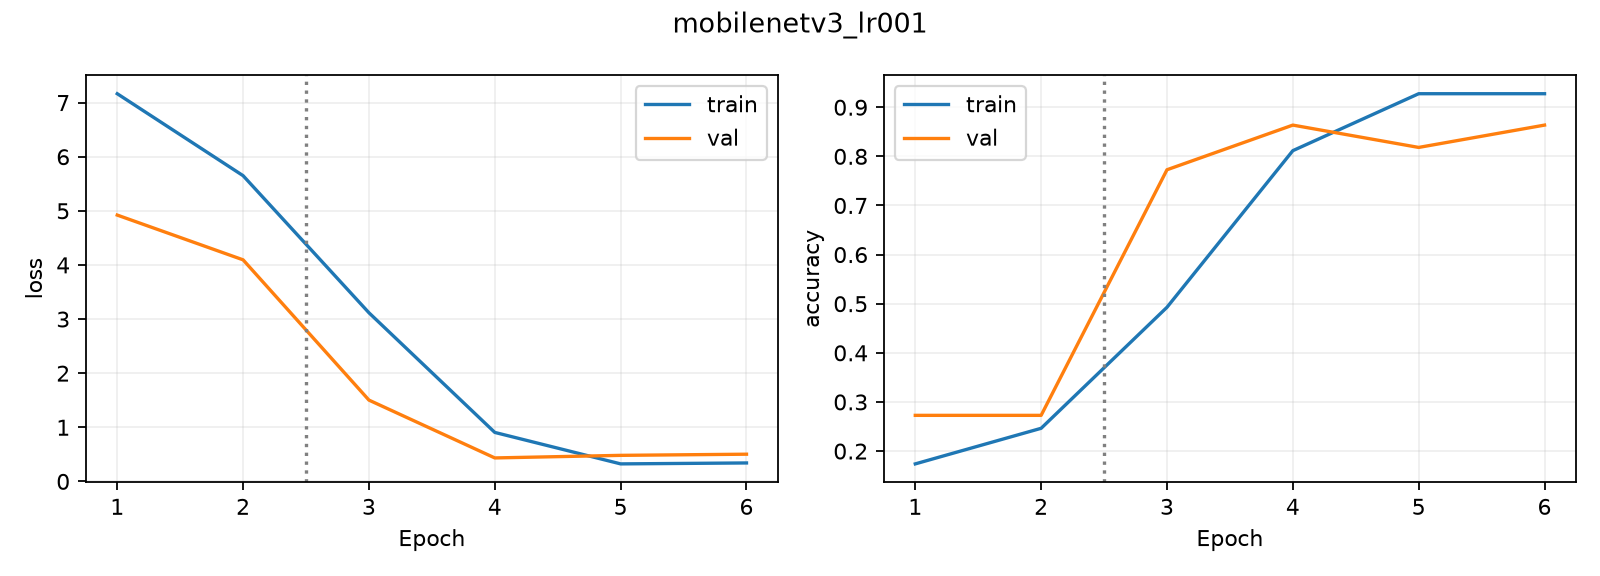

mobilenetv3_lr0003 val accuracy 0.7273 val loss 1.3771 seconds 8.9 parameters 1520931


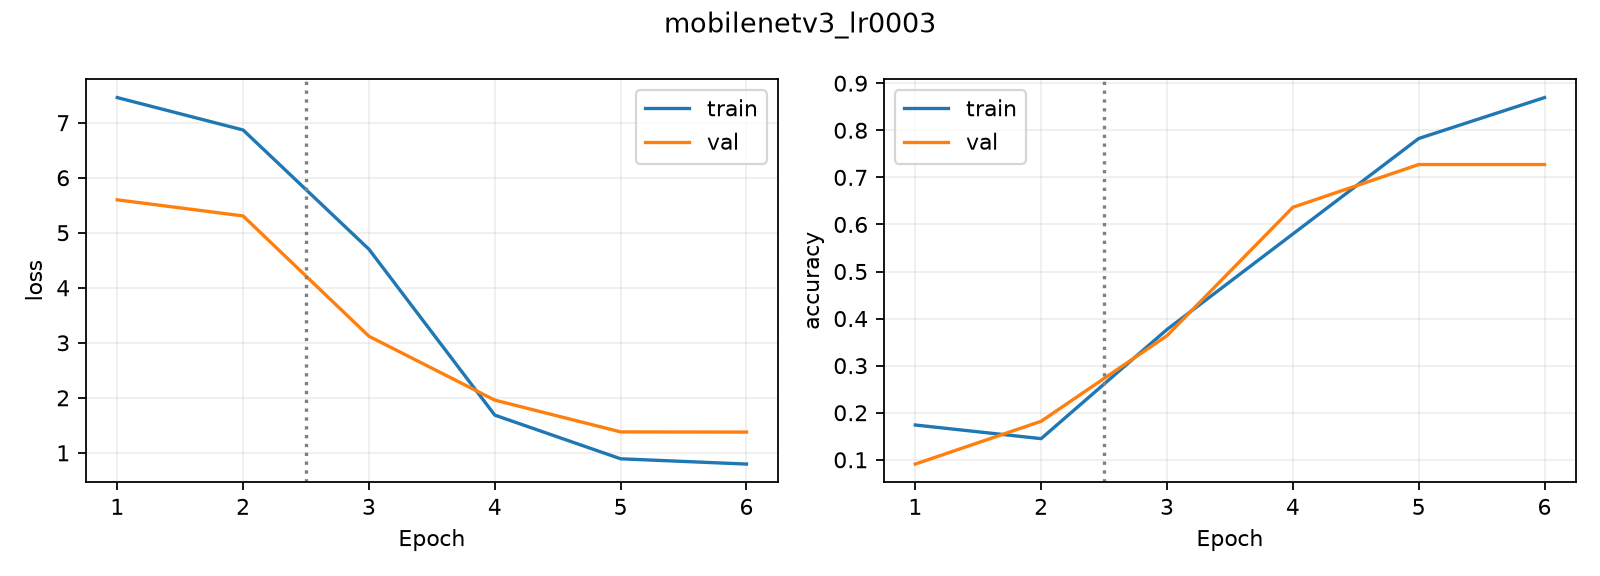

SELECTED BEFORE TEST: resnet18_lr001


99

In [4]:
def rank(r): return (r['best_validation_accuracy'], -r['best_validation_loss'])
winners = [max([r for r in runs if r['config']['model']==m], key=rank) for m in sorted({r['config']['model'] for r in runs})]
best = max(winners, key=rank)
for r in runs:
    print(r['config']['run_name'], 'val accuracy', round(r['best_validation_accuracy'],4),
          'val loss', round(r['best_validation_loss'],4), 'seconds', round(r['seconds'],1), 'parameters', r['parameters'])
    display(DisplayImage(filename=f"experiments/reports/figures/{r['config']['run_name']}.png"))
print('SELECTED BEFORE TEST:', best['config']['run_name'])
Path('experiments/reports/selection.json').write_text(json.dumps({'winner':best['config']['run_name'], 'families':[r['config']['run_name'] for r in winners]},indent=2))

## Итоговая оценка
Accuracy = число правильных ответов / число изображений. В матрице ошибок строки — истинный класс, столбцы — прогноз.
Для каждого семейства оцениваем только выбранный по validation checkpoint. Базовый уровень для сбалансированных трёх классов около 1/3.
При небольшом тесте одна ошибка существенно меняет процент; результат нельзя переносить на все фотографии насекомых.


mobilenetv3_lr001 {"accuracy": 0.92, "loss": 0.5390976041927934, "confusion_matrix": [[7, 0, 0], [0, 8, 1], [1, 0, 8]], "classes": ["butterfly", "dragonfly", "ladybird"], "predictions": [0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0], "targets": [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2]}


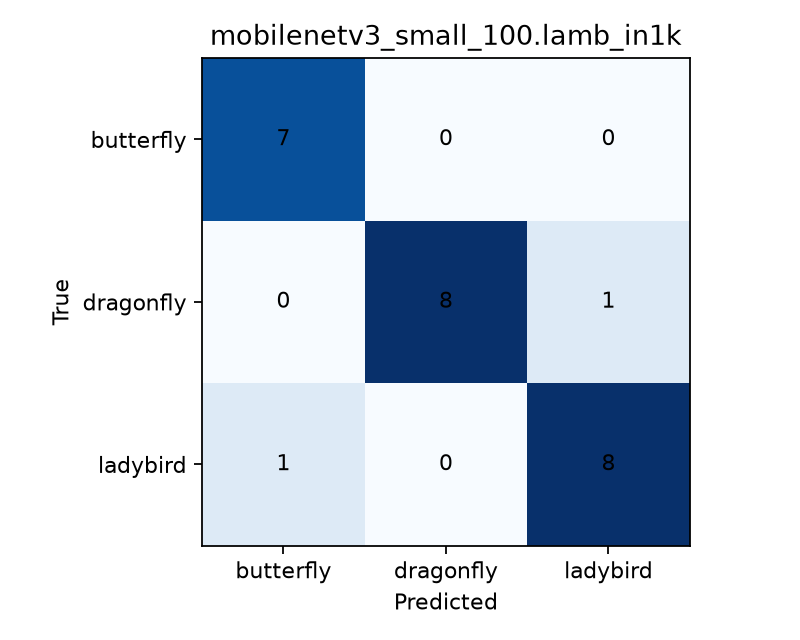

resnet18_lr001 {"accuracy": 1.0, "loss": 0.6254786801338196, "confusion_matrix": [[7, 0, 0], [0, 9, 0], [0, 0, 9]], "classes": ["butterfly", "dragonfly", "ladybird"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2], "targets": [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2]}


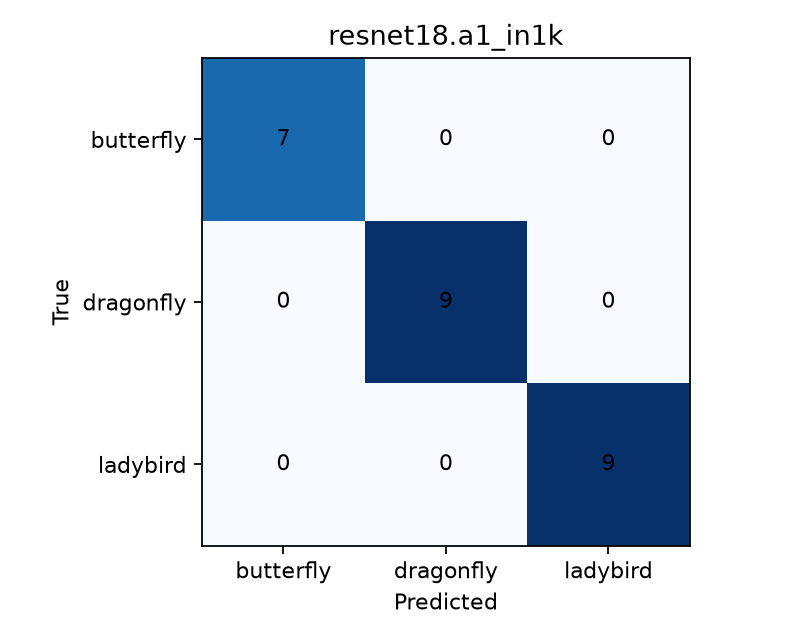

1680

In [5]:
tests={}
for r in winners:
    name=r['config']['run_name']
    tests[name]=test_checkpoint(ROOT/f'experiments/models/{name}.pt')
    print(name, json.dumps(tests[name], ensure_ascii=False))
    display(DisplayImage(filename=f'experiments/reports/figures/{name}_confusion.png'))
Path('experiments/reports/tests.json').write_text(json.dumps(tests,indent=2))

## ONNX и воспроизводимость
Экспортируем выбранную до просмотра test модель, opset=17, динамический batch, CPUExecutionProvider.
Проверяем структуру ONNX и численную близость логитов PyTorch и ONNX Runtime.
Повтор лучшего запуска с тем же seed проверяет все кривые обучения и веса; время исполнения не сравнивается.


In [6]:
best_path=ROOT/f"experiments/models/{best['config']['run_name']}.pt"
metadata=export_checkpoint(best_path)
print(json.dumps(metadata, indent=2))
repeat=train(replace(TrainConfig(**best['config']), run_name=best['config']['run_name']+'_repeat'))
assert repeat['history'] == best['history']
a=torch.load(best_path,map_location='cpu',weights_only=False)['state_dict']
b=torch.load(ROOT/f"experiments/models/{repeat['config']['run_name']}.pt",map_location='cpu',weights_only=False)['state_dict']
assert all(torch.equal(a[k],b[k]) for k in a)
Path('experiments/reports/reproducibility.json').write_text(json.dumps({'seed':42,'histories_equal':True,'weights_equal':True,'run':best['config']['run_name']},indent=2))
print('Same seed: histories and all checkpoint tensors are exactly equal.')

{
  "config": {
    "model": "resnet18.a1_in1k",
    "seed": 42,
    "image_size": 160,
    "batch_size": 8,
    "epochs": 6,
    "freeze_epochs": 2,
    "lr_head": 0.001,
    "lr_backbone": 0.0001,
    "weight_decay": 0.0001,
    "num_workers": 0,
    "threads": 2,
    "run_name": "resnet18_lr001",
    "data_dir": "experiments/data/raw",
    "manifest": "experiments/data/processed/split.csv",
    "mean": [
      0.485,
      0.456,
      0.406
    ],
    "std": [
      0.229,
      0.224,
      0.225
    ]
  },
  "classes": [
    "butterfly",
    "dragonfly",
    "ladybird"
  ],
  "epoch": 2,
  "max_export_error": 1.7881393432617188e-07
}


resnet18_lr001_repeat {'epoch': 1, 'stage': 'head', 'train_loss': 1.0698624641998955, 'train_accuracy': 0.43478260869565216, 'val_loss': 0.8532678213986483, 'val_accuracy': 0.9090909090909091}


resnet18_lr001_repeat {'epoch': 2, 'stage': 'head', 'train_loss': 0.7911216262458027, 'train_accuracy': 0.8840579710144928, 'val_loss': 0.6267333030700684, 'val_accuracy': 1.0}


resnet18_lr001_repeat {'epoch': 3, 'stage': 'all', 'train_loss': 0.971261713815772, 'train_accuracy': 0.5652173913043478, 'val_loss': 0.6495292945341631, 'val_accuracy': 0.9545454545454546}


resnet18_lr001_repeat {'epoch': 4, 'stage': 'all', 'train_loss': 0.7701970788015835, 'train_accuracy': 0.8695652173913043, 'val_loss': 0.6480328603224321, 'val_accuracy': 0.9545454545454546}


resnet18_lr001_repeat {'epoch': 5, 'stage': 'all', 'train_loss': 0.6527727254922839, 'train_accuracy': 0.9420289855072463, 'val_loss': 0.6020404208790172, 'val_accuracy': 0.9545454545454546}


resnet18_lr001_repeat {'epoch': 6, 'stage': 'all', 'train_loss': 0.5720577663269596, 'train_accuracy': 0.9130434782608695, 'val_loss': 0.5580040975050493, 'val_accuracy': 0.9545454545454546}


Same seed: histories and all checkpoint tensors are exactly equal.


## Проверка приложения на тестовых фотографиях
Проверка ниже использует настоящие тестовые изображения, а не только случайный вход.
Классы и нормализация считываются из экспортированных метаданных.


In [7]:
from experiments.verify_export import verify
verification=verify(best_path)
print(json.dumps(verification, indent=2))

{
  "test_images": 25,
  "max_logit_error": 1.1324882507324219e-06,
  "predictions_equal": true,
  "preprocessing_equal": true,
  "onnx_megabytes": 44.702738,
  "cpu_median_ms": 8.398400008445606,
  "cpu_p95_ms": 9.810135007137433,
  "timing": "batch 1, two CPU threads, 10 warmup + 50 runs, preprocessing excluded"
}


# Результаты и интерпретация

Все числа получены исполнением notebooks/lab3.ipynb на CPU 07.09.2026. Train 69, validation 22, test 25; 68 непересекающихся между частями авторских групп.

| Запуск | LR головы | Лучшая эпоха | Val accuracy | Val loss | Время 6 эпох, с |
|---|---:|---:|---:|---:|---:|
| ResNet18 | 0.001 | 2 | 1.0000 | 0.6267 | 22.31 |
| ResNet18 | 0.0003 | 2 | 0.8182 | 0.9515 | 21.46 |
| MobileNetV3 Small | 0.001 | 4 | 0.8636 | 0.4337 | 8.96 |
| MobileNetV3 Small | 0.0003 | 6 | 0.7273 | 1.3771 | 8.95 |

При равной validation accuracy выбирается меньшая validation loss. Скорость измерена после создания модели, без загрузки pretrained весов и финального построения графиков; это время конкретной машины, а не универсальный benchmark.

## Выбор и тест

До просмотра теста выбрана ResNet18, LR головы 0.001, backbone 0.0001, checkpoint эпохи 2. Вся процедура содержит 6 эпох и реальное размораживание с эпохи 3, однако лучший checkpoint относится к этапу обучения головы. Поэтому экспортированный backbone сохранил pretrained веса. Это наблюдаемый результат отбора, а не утверждение, что размораживание всегда вредно.

| Семейство | Test accuracy | Правильно | Test loss | Параметров |
|---|---:|---:|---:|---:|
| ResNet18 | 100% | 25/25 | 0.6255 | 11 178 051 |
| MobileNetV3 Small | 92% | 23/25 | 0.5391 | 1 520 931 |

ResNet18 имеет в 7.35 раза больше параметров и обучалась примерно в 2.5 раза дольше, но показала большую accuracy. MobileNetV3 компактнее и имеет меньшую test cross-entropy, несмотря на две ошибки: accuracy учитывает только argmax, loss также зависит от уверенности. Выбор сделан по заранее определённому критерию accuracy.

## Кривые

У ResNet18 validation accuracy достигает 22/22 на эпохе 2; после перехода к обучению всей сети остаётся 21/22. В начале нового этапа train accuracy падает: меняются режим BatchNorm и набор обучаемых параметров. Нельзя приписать весь эффект только переобучению. Позже validation loss уменьшается, но accuracy не возвращается к 100%.

MobileNetV3 при LR=0.001 заметно улучшается после размораживания: validation accuracy растёт с 27.3% до 86.4%. На эпохах 5–6 train accuracy около 92.8%, validation loss выше минимума эпохи 4 — ограниченный признак начала переобучения. Малый LR=0.0003 в данном бюджете эпох уступает для обеих моделей; это не доказывает, что он хуже при длительном обучении.

Train-кривые измерены на случайных аугментациях в ходе обновления весов; validation — без аугментаций на модели в конце эпохи. Поэтому validation accuracy может быть выше train, и прямое сравнение их разрыва требует осторожности.

## Матрицы ошибок и примеры

Порядок классов: butterfly, dragonfly, ladybird; строки — истина, столбцы — прогноз.

ResNet18: `[[7,0,0],[0,9,0],[0,0,9]]`.
MobileNetV3: `[[7,0,0],[0,8,1],[1,0,8]]`.

MobileNetV3 ошиблась на:
- dragonfly/113143673.jpg → ladybird: стрекоза с малоконтрастными прозрачными крыльями на тонкой вертикальной ветке;
- ladybird/185666756.jpg → butterfly: небольшой жук на фактурном стебле, значительная часть изображения занята фоном.

Связь ошибок с масштабом и фоном — визуальная гипотеза, не доказанная атрибуцией признаков. Для следующего независимого эксперимента можно собрать больше малоконтрастных сцен, попробовать bounding-box crop или аугментацию фона. Текущий тест после анализа не использовался для нового подбора.

## ONNX и повторяемость

Экспорт opset 17, вход batch×3×160×160 float32, выход batch×3 logits. Размер 44.70 MB. Проверены onnx.checker, случайный вход, все 25 настоящих test изображений и точное совпадение eval-предобработки с app/preprocessing.py.
Максимальное расхождение логитов PyTorch/ORT на тесте 1.13e-6; все argmax совпали. Медиана CPU-инференса batch=1 — 8.40 мс, p95 — 9.81 мс (два потока, 10 прогревов + 50 измерений, без предобработки).
Повтор лучшего запуска с seed=42 дал точно одинаковые истории и все тензоры checkpoint. Это проверка на одной машине и одном окружении, не обещание побитовой идентичности на любом железе.

## Ограничения

25/25 на небольшом тесте не означает 100% на генеральной совокупности. Один неверный ответ меняет accuracy на 4 процентных пункта. В коллекции один вид на каждую визуальную группу; неизвестных классов нет. Оценка не распространяется на всех насекомых, а softmax не является калиброванной уверенностью.

## Сопоставление с образцом

В отчёте Шатило сравниваются ResNet18 и EfficientNet-B0 на 180 сценах forest/mountain/sea, 20 эпох. Его test accuracy 76.67% и 93.33% получены на других данных, поэтому прямой рейтинг с нашими 100% и 92% некорректен.
Сохранён общий порядок отчёта: цель, данные, архитектуры, обучение, метрики, матрицы, экспорт, вывод.
В предоставленном тексте ONNX и Gradio описаны в будущем/условном времени; файлы экспорта и приложения им не подтверждены. В нашем проекте они выполнены и проверены.
Дополнительно имеются четыре конфигурации поиска, манифест происхождения и лицензий, разделение по авторам и проверка повторяемости.
В образце титул говорит о листьях, а основная часть — о природных сценах; в новом отчёте тема едина.


Приложение проверено через API и браузер, включая загрузку файла и вывод класса.
